# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

> ✅ **Updated version:** This version completes the exercises from the original template — it adds `EarlyStopping`, actually trains the data-augmented CNN (it was previously commented out), fixes a deprecation issue with how the input shape was declared, and extends the final comparison to all three models.


# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

> 💡 This downloads the dataset from the internet the first time it runs, so make sure you're connected (this works out of the box on Google Colab).


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 573s 3us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

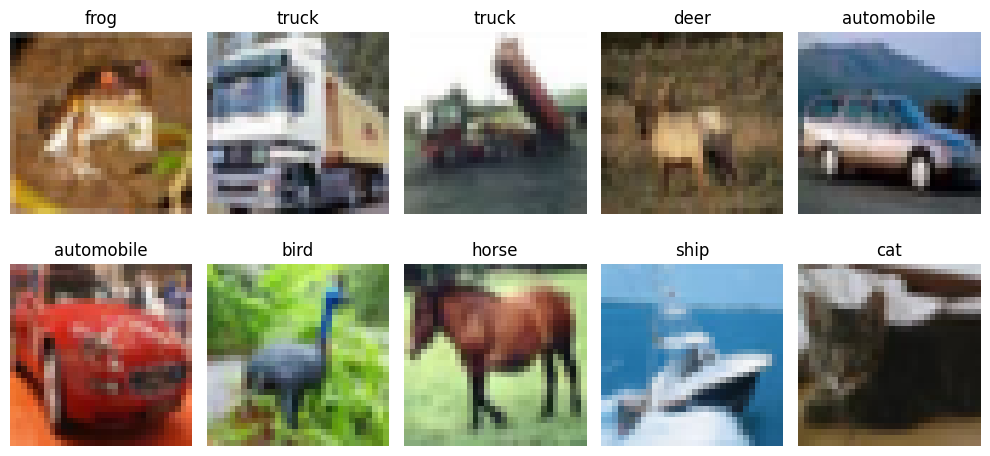

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.


In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

> 🛑 **EarlyStopping**: we monitor validation loss and stop training automatically once it stops improving, restoring the best weights seen. This avoids wasting epochs and reduces overfitting — one of the "Student Learning Tasks" from below, now built in.


In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.2688 - loss: 1.9974 - val_accuracy: 0.3160 - val_loss: 1.8594
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.3087 - loss: 1.8832 - val_accuracy: 0.3346 - val_loss: 1.8180
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3326 - loss: 1.8254 - val_accuracy: 0.3414 - val_loss: 1.7857
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3456 - loss: 1.7896 - val_accuracy: 0.3800 - val_loss: 1.7346
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3551 - loss: 1.7625 - val_accuracy: 0.3728 - val_loss: 1.7395
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3643 - loss: 1.7405 - val_accuracy: 0.4086 - val_loss: 1.7049
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3714 - loss: 1.7244 - val_accuracy: 0.4058 - val_loss: 1.6994
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3767 - loss: 1.7086 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4387 - loss: 1.5909
ANN Test Accuracy: 0.43869999051094055


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.


In [7]:
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 124ms/step - accuracy: 0.4650 - loss: 1.5006 - val_accuracy: 0.5742 - val_loss: 1.1871
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.6045 - loss: 1.1280 - val_accuracy: 0.4884 - val_loss: 1.6892
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.6713 - loss: 0.9546 - val_accuracy: 0.6260 - val_loss: 1.0753
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7117 - loss: 0.8248 - val_accuracy: 0.6456 - val_loss: 1.0827
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7454 - loss: 0.7241 - val_accuracy: 0.6882 - val_loss: 0.9451
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.7715 - loss: 0.6498 - val_accuracy: 0.6788 - val_loss: 0.9530
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - accuracy: 0.7946 - loss: 0.5855 - val_accuracy: 0.7238 - val_loss: 0.8345
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.8128 - loss:

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7173 - loss: 0.8772
CNN Test Accuracy: 0.7172999978065491


## 📈 Compare Learning Curves: ANN vs CNN

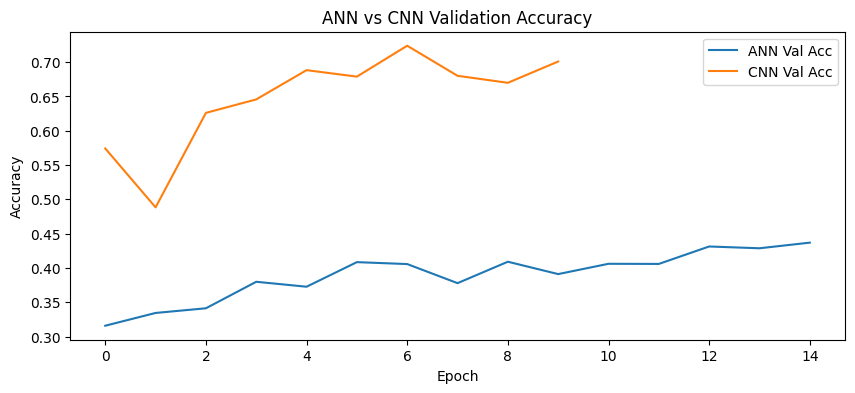

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()


# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed (flipped, rotated, zoomed) versions of training images on the fly, so the model sees more variety without needing more data.

Below we build a CNN with an augmentation pipeline **and now actually train it**, so we can compare it fairly against the plain CNN above.


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 91ms/step - accuracy: 0.3700 - loss: 1.7306 - val_accuracy: 0.4556 - val_loss: 1.5521
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.4678 - loss: 1.4806 - val_accuracy: 0.5320 - val_loss: 1.3094
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5044 - loss: 1.3857 - val_accuracy: 0.5626 - val_loss: 1.2217


In [11]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4561 - loss: 1.5452
Augmented CNN Test Accuracy: 0.4560999870300293


## 📈 Compare Learning Curves: All Three Models

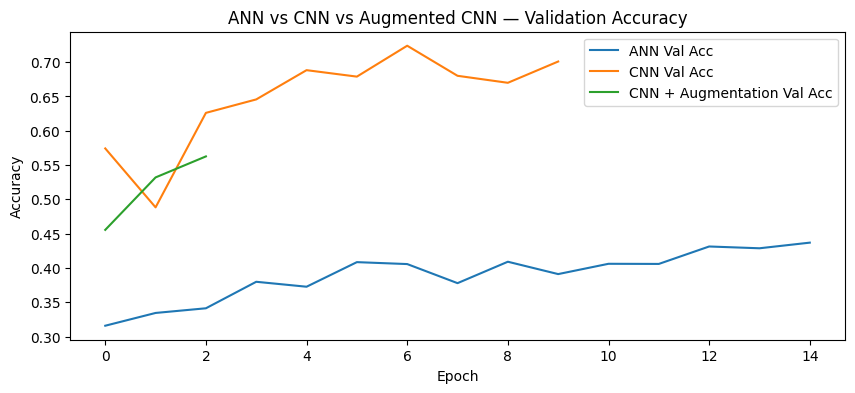

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN vs Augmented CNN — Validation Accuracy")
plt.legend()
plt.show()


# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison


,Model,Test Accuracy
0,ANN,0.4387
1,CNN,0.7173
2,CNN + Augmentation,0.4561


# 🎓 Student Learning Tasks
Built into this version already: ✅ EarlyStopping, ✅ data-augmentation training, ✅ CNN filter progression (32→64→128), ✅ longer training (15 epochs, guarded by early stopping).

### ✅ Try these next
1. Increase ANN layers/width and see if it closes the gap with CNN (it won't close much — that's the point!)
2. Try a deeper CNN (add a 4th conv block) and compare
3. Tune augmentation strength (`RandomRotation`, `RandomZoom` factors) and see the effect on the val-accuracy gap between CNN and CNN+Augmentation
4. Add a learning-rate scheduler (`ReduceLROnPlateau`) alongside EarlyStopping
5. Plot a confusion matrix for the best model to see which classes get confused most (e.g. cat vs dog)


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results — augmentation in particular tends to narrow the gap between training and validation accuracy (less overfitting) even if it doesn't always raise peak validation accuracy in a short run
- **EarlyStopping** keeps training efficient and prevents needlessly overfitting once validation loss stops improving
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**
